In [28]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

from PIL import Image

In [29]:
train_folder = "train"
test_folder = "test"

In [30]:
train_labels = []
train_paths = []

for category in os.listdir(train_folder):
    category_path = os.path.join(train_folder, category)
    
    for img_name in os.listdir(category_path):
        if category == "disgust":
            category = "angry"
        train_labels.append(category) 
        train_paths.append(os.path.join(category_path, img_name))

In [31]:
train_paths[1]

'train\\angry\\Training_10120469.jpg'

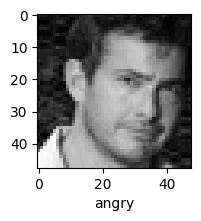

In [32]:
sample_img = Image.open(train_paths[1])

plt.figure(figsize=(3,2))
plt.imshow(sample_img, cmap="gray")
plt.xlabel(train_labels[1])
plt.show()

In [33]:
np.array(sample_img).shape

(48, 48)

In [34]:
print("Total training labels:", len(train_labels))
print("Total training images:", len(train_paths))

Total training labels: 28709
Total training images: 28709


In [35]:
train_images = []

for img_path in train_paths:
    img = Image.open(img_path)
    train_images.append(np.array(img))

In [36]:
train_images[1]

array([[ 29,  24,  29, ...,  11,  12,  17],
       [ 17,  14,  14, ...,  15,  20,  23],
       [  0,   4,   3, ...,  33,  35,  23],
       ...,
       [250, 248, 247, ...,  44,  47,  43],
       [247, 248, 248, ...,  41,  58,  55],
       [249, 248, 244, ...,  15,  24,  24]], shape=(48, 48), dtype=uint8)

In [37]:
train_images[1].shape

(48, 48)

In [38]:
X_train = np.array(train_images)
X_train = X_train / 255.0

y_train = np.array(train_labels)

In [39]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)

In [40]:
test_labels = []
test_paths = []

for category in os.listdir(test_folder):
    category_path = os.path.join(test_folder, category)

    for img_name in os.listdir(category_path):

        if category == "disgust":
            category = "angry"

        test_labels.append(category)
        test_paths.append(os.path.join(category_path, img_name))

In [41]:
print("Total test images:", len(test_paths))
print("Total test labels:", len(test_labels))

Total test images: 7175
Total test labels: 7175


In [42]:
test_images = []

for path in test_paths:
    img = Image.open(path)
    test_images.append(np.array(img))

In [43]:
X_test = np.array(test_images)
X_test = X_test / 255.0

y_test = np.array(test_labels)

In [44]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(64, activation='relu'),
    Dense(7, activation='softmax')
])

c:\Users\kaush\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
cnn_model.fit(X_train, y_train, epochs=20, batch_size=30)

Epoch 1/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.3377 - loss: 1.6195
Epoch 2/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4635 - loss: 1.3707
Epoch 3/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.5134 - loss: 1.2594
Epoch 4/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5404 - loss: 1.1956
Epoch 5/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5609 - loss: 1.1426
Epoch 6/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5805 - loss: 1.0994
Epoch 7/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5927 - loss: 1.0664
Epoch 8/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.6056 - loss: 1.0294
Epoch 9/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.6179 - loss: 1.0048
Epoch 10/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.6289 - loss: 0.9758
Epoch 11/20
957/957 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.6428 - loss: 0.9442
Epoch 12/20
957/957 ━━━━━━━━━━

In [47]:
pred = cnn_model.predict(X_test)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [48]:
print("Shape of y_test:", y_test.shape)
print("Shape of predictions:", pred.shape)
print("Shape of X_test:", X_test.shape)

Shape of y_test: (7175,)
Shape of predictions: (7175, 7)
Shape of X_test: (7175, 48, 48)


In [49]:
pred = np.argmax(pred, axis=1)
pred = encoder.inverse_transform(pred)

In [50]:
from sklearn.metrics import accuracy_score

print(pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": pred[:10]
}))

print("Model Accuracy:", accuracy_score(y_test, pred))

  Actual Predicted
0  angry       sad
1  angry     angry
2  angry      fear
3  angry     angry
4  angry     angry
5  angry   neutral
6  angry     angry
7  angry     angry
8  angry   neutral
9  angry       sad
Model Accuracy: 0.5705923344947735


In [51]:
import os
print(os.listdir("train"))

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
